<h3>Libraries</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Importing Data</h3>

In [2]:
# Display settings — makes output cleaner
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('C:/Users/Lenovo/churn-predictor/data/raw/telco_churn.csv')

In [3]:
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<h3>PreProccessing</h3>

In [4]:
#understaning what all columns are there
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Initial observations
- 7043 rows, 21 columns
- Target column: Churn (Yes/No)
- TotalCharges is object type — needs fixing (has whitespace values)
- customerID is just an identifier — will be dropped before modelling
- No obviously missing values shown, but TotalCharges has hidden nulls

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print()
print(churn_pct.round(1))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No    73.50
Yes   26.50
Name: proportion, dtype: float64


## Class imbalance
26.5% churn rate. This means:
- Accuracy is a misleading metric (a model that always predicts No gets 73.5%)
- We'll use ROC-AUC and PR-AUC as primary metrics
- Will apply scale_pos_weight in XGBoost to compensate

In [6]:
# Separate columns by type — you'll use this list throughout the project
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
categorical_cols = [c for c in df.columns
                    if c not in numerical_cols + binary_cols + ['customerID',
                    'MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaymentMethod']]

# Multi-value categoricals (3+ categories)
multicat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

print("Numerical:", numerical_cols)
print("Binary:", binary_cols)
print("Multi-category:", multicat_cols)

Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges']
Binary: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
Multi-category: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [7]:
# Standard missing value check
print(df.isnull().sum())
print()

# TotalCharges has whitespace strings, not NaN — catch them like this
total_charges_issues = df[df['TotalCharges'].str.strip() == '']
print(f"TotalCharges whitespace rows: {len(total_charges_issues)}")
print(total_charges_issues[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

TotalCharges whitespace rows: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218 

## Missing data finding
11 rows have blank TotalCharges — all have tenure=0 (new customers, no bill yet).
Strategy: convert to float, fill these 11 with 0 (not mean imputation — 
mean would be wrong here, 0 is the correct business value).

In [8]:
# Convert TotalCharges temporarily just for this summary
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')

df_temp[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.47
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


<h4>Fix TotalCharges before plotting</h4>

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# The 11 blank rows become NaN — fill with 0 (new customers, no bill yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify the fix
print(df['TotalCharges'].isnull().sum())
print(df['TotalCharges'].dtype)

0
float64


<h4>Histograms of all three numerical features</h4>

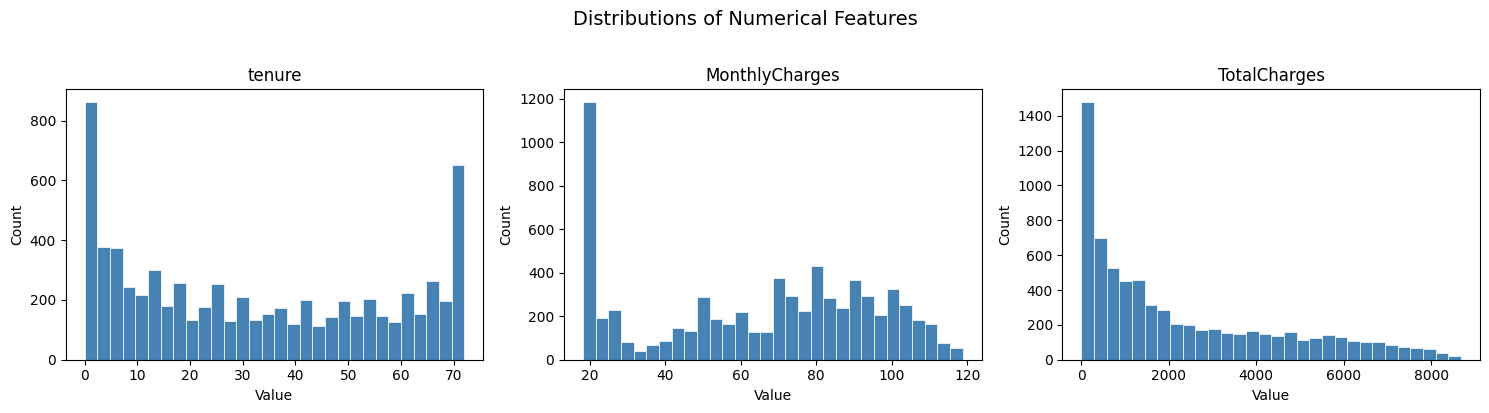

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Distributions of Numerical Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('C:/Users/Lenovo/churn-predictor/reports/figures/histograms_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

## Histogram observations

- tenure: bimodal distribution — large spike at 0-5 months (new/churned customers)
  and another at 60-72 months (loyal long-term customers). Very little in the middle.
  
- MonthlyCharges: roughly uniform between $20-$100, with a spike at the low end
  (~$20) likely representing basic phone-only plans.

- TotalCharges: right-skewed — most customers have low total spend, 
  a tail of high-value long-tenure customers. This is expected given 
  TotalCharges = MonthlyCharges × tenure approximately.

<h4>Overlay churn on the histograms</h4>

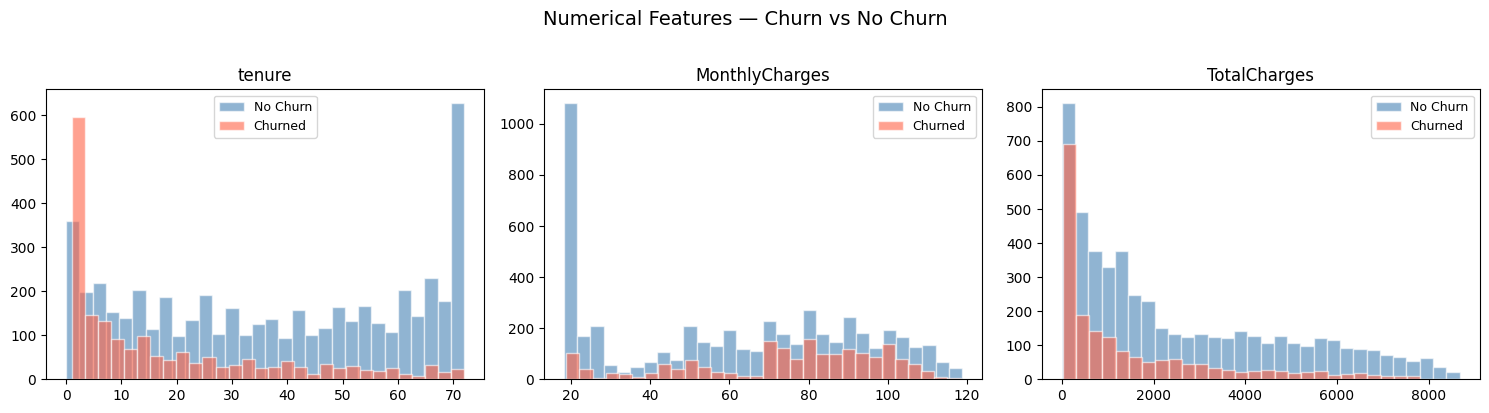

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    # Plot non-churners and churners as overlapping histograms
    ax.hist(df[df['Churn']=='No'][col],  bins=30, alpha=0.6,
            label='No Churn', color='steelblue', edgecolor='white')
    ax.hist(df[df['Churn']=='Yes'][col], bins=30, alpha=0.6,
            label='Churned',  color='tomato',    edgecolor='white')
    ax.set_title(col)
    ax.legend(fontsize=9)

plt.suptitle('Numerical Features — Churn vs No Churn', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('C:/Users/Lenovo/churn-predictor/reports/figures/histograms_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## Churn overlay observations

- tenure: churners are heavily concentrated in the first 1-12 months.
  Customers who stay beyond 2 years almost never churn.
  → tenure is likely the strongest predictor.

- MonthlyCharges: churners skew toward higher charges ($60-$100 range).
  Low-charge customers rarely churn.
  → high monthly cost is a churn risk signal.

- TotalCharges: churners cluster at low values — consistent with short tenure.
  Not independently informative once you have tenure + MonthlyCharges.

<h4>Box plots split by churn</h4>

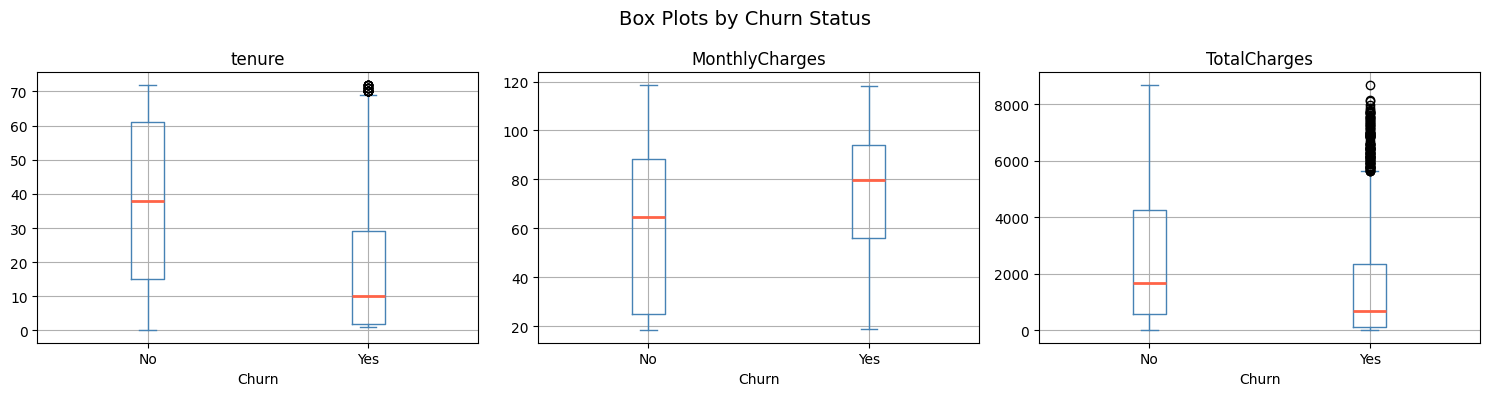

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    df.boxplot(column=col, by='Churn', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2),
               whiskerprops=dict(color='steelblue'),
               capprops=dict(color='steelblue'))
    ax.set_title(col)
    ax.set_xlabel('Churn')

plt.suptitle('Box Plots by Churn Status', fontsize=14)
plt.tight_layout()
plt.savefig('C:/Users/Lenovo/churn-predictor/reports/figures/boxplots_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## Box plot observations

- tenure: median churn ~10 months vs median no-churn ~38 months. 
  Largest separation of any feature — confirms it as top predictor.

- MonthlyCharges: median churn ~$75 vs median no-churn ~$61. 
  Clear signal, but overlap is large — not sufficient alone.

- TotalCharges: overlapping IQRs — less discriminative than the other two.
  Supports the idea that derived feature charges_per_month will be more useful.

<h4>Correlation Heatmap</h4>

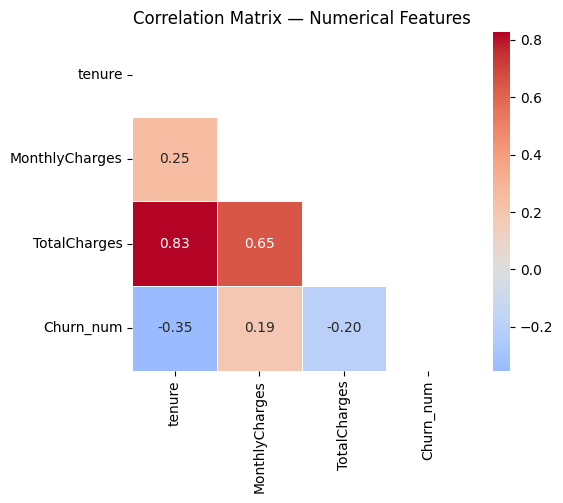

In [14]:
# Only numerical columns + encoded target for the heatmap
df_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
df_corr['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

corr = df_corr.corr()

plt.figure(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.savefig('C:/Users/Lenovo/churn-predictor/reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation findings

- tenure vs TotalCharges: 0.83 — very high. Makes sense: longer tenure → 
  more total spend. This is multicollinearity. Both columns shouldn't be 
  treated as independent signals. Our derived feature charges_per_month 
  will address this.

- MonthlyCharges vs TotalCharges: 0.65 — moderate. Same reason above.

- tenure vs Churn: -0.35 — negative, as expected (longer tenure = less churn).
- MonthlyCharges vs Churn: +0.19 — positive (higher charges = more churn).
- TotalCharges vs Churn: -0.20 — negative, driven by the tenure relationship.

Takeaway: tenure and MonthlyCharges are the real signals. 
TotalCharges is largely redundant given those two.